# Forecasting with gradient-boosted trees

Same job as notebook 02, with a different model family: XGBoost quantile regression instead of a Temporal Fusion Transformer.

**Why bother running a second model at all.** This one is much cheaper, and reproduces exactly:

| | TFT | this |
|---|---|---|
| reproducible | needs a GPU | **exactly, on a CPU** |
| one fit | hours | **~1 minute** |
| pinball | 0.1074 | 0.1116 |

So the TFT is ahead here by about 3.9% on pinball — a real gap, but a modest one (see README §6 for the full picture; an earlier draft of this project mis-stated it as "under 1% apart," which was a stale reading from before the TFT was last re-run). Gradient boosting isn't an easy target either — it's what wins competitions on this exact problem shape (hierarchical retail unit sales, intermittent, with calendar and price covariates), so this comparison is a genuine test of the transformer, not a strawman.

| Step | What it does |
|---|---|
| 1 | load the recovered demand |
| 2 | grid search, check for overfitting, then train the winner |
| 3 | compare against the baselines and the TFT |
| 4 | train on raw sales — does recovery help? |
| 5–6 | where recovery helps, and what the trade costs |

## Setup

In [ ]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root goes on the path

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

from src.utils import config, plots
from src.utils.features import censoring_bucket
from src.utils.metrics import pinball_by_quantile, quantile_scores, scores_by_bucket, lost_sales_vs_waste
from src import gbm, recovery   # the tree forecaster, and the same recovery loader notebook 02 uses

## 1. Load the recovered demand

One pair of parquet files: the recovered files hold every raw column **plus** `recovered_demand`. The lag and `period` columns get rebuilt on load, so a saved column can never end up describing a subset that's since been redrawn.

In [ ]:
daily = recovery.load_daily("recovered")

# Fail loudly and early if notebook 01's recovery step hasn't produced this column yet.
assert daily["recovered_demand"].notna().all(), "recovered_demand missing - run notebook 01 step 4"
print(f"{len(daily):,} rows | recovery model:", recovery.load_params()["model"])
daily.groupby("period")[["sale_amount", "recovered_demand"]].mean().round(4)

## 2. Grid search

Nine configs, and every score here is exactly reproducible — so unlike the TFT's ranking, any difference we see, however small, is real.

Each config gets **its own round count** from early stopping, reported as `best_round`. That's the whole point of setting the grid up this way. An earlier version of this search pinned `n_estimators` at 200 for everyone, which quietly rigged the learning-rate comparison: a lower rate needs more trees to get to the same place, so judging 0.02 against 0.05 at one fixed budget was really asking the slow learner to finish in the fast learner's time. That's the one interaction the previous 36-config search couldn't see, and in boosting it's usually where the last bit of accuracy hides.

| axis | why these values |
|---|---|
| `learning_rate` | 0.05 won at a fixed 200 rounds; 0.02 and 0.03 are the ones that had been unfairly handicapped |
| `max_depth` | 5 and 7 had never actually been tried — 3, 4, 6, 8, 10 had, and 6 won |

Everything else stays at its measured best (`gbm.FIXED`), since each of those settings was tested individually at depth 6, against its own best round count, and every alternative lost — see the regularisation notes below.

Early stopping watches the last 14 days of **training**, never validation. Stopping on validation would let the model pick its own size using the exact window it's later scored on — that's what the TFT does, and copying it here would make this model's number flattering rather than genuinely comparable.

**Ranked on pinball, not WAPE.** The ordering stage reads a quantile straight off this forecast, and pinball at that quantile is the newsvendor cost function up to a constant. WAPE doesn't care about direction, so it can't rank a policy whose whole job is choosing which way to lean. `pinball@0.8` sits next to it because that's the quantile the order actually gets read at, and `pinball(avg)` never covers it — it only averages q10/q50/q90, so three of the six quantiles we fit would otherwise be trained and never scored.

Fitting all six quantiles in one model is also the right call, and it's measured rather than assumed: against fitting only `[0.5, 0.8]`, the full six scored **0.13274** at q80 versus **0.13344**. The extreme tails don't steal capacity from the middle — sharing trees across quantiles actually regularises the fit, so more quantiles turns out slightly better even at the one that matters most.

Budget roughly two fits per config, and expect the lower learning rates to take several times longer than 0.05.

In [ ]:
TUNE = False   # False = load the saved ranking

# Fit all nine configs fresh (each gets its own early-stopped round count), or just load the ranking.
tuning = (gbm.tune(daily) if TUNE
          else pd.read_csv(config.gbm_tuning("recovered")))
tuning.round(4)

### Train the winner on both targets

Same settings for both — the comparison has to change only the target, never the configuration.

`best_params` carries `best_round` through as `n_estimators`, so the model trained here ends up the same size as the one the ranking actually scored. Dropping that would train a differently-sized model than the one the search measured.

In [ ]:
BEST = gbm.best_params(tuning)
print("winning config:", BEST)

PERIODS = ("validation", "calibration", "test")
# Train the winning config twice, once per target, so raw and recovered stay directly comparable.
recovered = gbm.run(daily, tag="recovered", periods=PERIODS, **BEST)
raw = gbm.run(daily, tag="raw", periods=PERIODS, **BEST)

recovered["validation"][["dt", "store_id", "product_id",
                         "q10", "q50", "q80", "q90", "sale_amount", "is_censored"]].head()

### Is the winner overfitting?

The grid can't answer this on its own, even with early stopping. Stopping just picks a round count by watching a held-back slice — it never shows the **gap** between training and validation loss, so it can tell you when to stop without ever telling you whether the model is memorising. That gap simply isn't something a grid search produces.

**The curve below is a by-product of the fit above, not a second fit.** `gbm.run` attaches both train and validation as eval sets, so XGBoost records the loss on both after every boosting round, during the fit that had to happen anyway. The only extra cost is one prediction per round, on rows already sitting in memory.

That replaces an older approach that called `gbm.learning_curve` separately, fitting a **second** model at twice the winner's round count purely to draw this chart — and it turns out that doubling wasn't even necessary. Validation loss bottoms out at round **290**, while the tuned winner runs for **430** rounds, so the turning point was already inside the range we fitted anyway; the extra rounds in that old version just drew a flat tail. `gbm.learning_curve` still exists for the one thing this shortcut can't show — the region *past* the chosen round count — but nothing here needs that.

**What the numbers below show.** The chosen config sits about **140 rounds past** the validation minimum, at a cost of only **0.00018** in loss. So yes, the curve does turn upward eventually, and 430 rounds is on the far side of that turn — but only by a negligible margin. Two reasons that's not evidence the grid search picked wrong:

- **These are two different measurements, not the same thing twice.** `best_round` comes from early stopping on held-back **training** days, scored with `metrics.quantile_scores` against recorded `sale_amount` on non-stockout rows. This curve is XGBoost's own internal loss against the **training target**, on *all* validation rows. Different rows, different target, different code path.
- **The margin is smaller than the gap between adjacent rows in the grid** (0.1144 vs 0.1145 in the ranking above), so it's not a distinction the search could ever have resolved anyway.

**A gap between train and validation loss isn't automatically a fault.** Training loss is measured on the very rows the model fitted, so it's optimistically biased by construction — any model with real capacity will score better in-sample than out. The validation window is also a later period, with its own weather, promotions and holidays, so part of the gap is just the data changing, not the model failing. A gap of exactly zero would actually mean a model with no capacity at all. What signals genuine overfitting is whether *more* capacity makes validation loss **worse**, and that's what the turning point in the chart is checking for.

Two things this y-axis is **not**. It's loss against `recovered_demand` on all validation rows, while the scorecard scores against recorded `sale_amount` on non-stockout rows only — so its level isn't comparable to `pinball(avg)`. And it's XGBoost's own internal averaging, not `quantile_scores`. Read the **shape** of the curve, not its absolute level.

curve covers 430 rounds | chosen n_estimators=430 | validation bottoms at round 290
loss at chosen=0.09125  best=0.09107  cost of the 140 rounds past the turn=0.000178
gap to train at chosen=0.01602


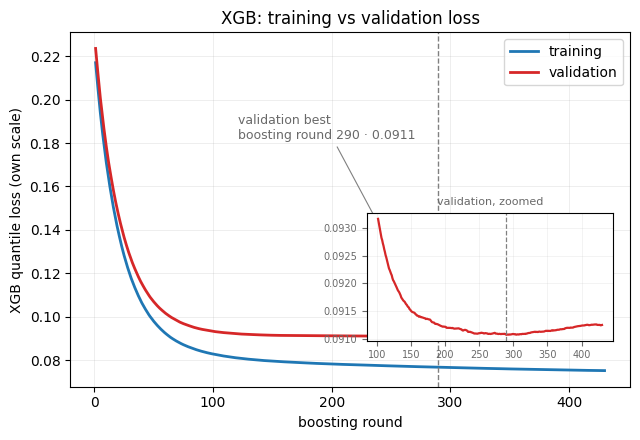

In [5]:
# No fit here, and no flag. `gbm.run` above recorded the curve as a by-product of the fit it had to
# do anyway, so this cell only reads what that wrote - one model instead of two.
curve = pd.read_csv(config.learning_curve_csv("xgb", "recovered"))

# The TFT writes its own curve on any fit with save_checkpoint=True. Absent until notebook 02 is
# re-run on a GPU, so the figure renders with one panel or two depending on what exists.
tft_path = config.learning_curve_csv("tft", "recovered")
curves = {"xgb": curve} | ({"tft": pd.read_csv(tft_path)} if tft_path.exists() else {})

chosen = BEST["n_estimators"]
turn = int(curve.loc[curve.validation.idxmin(), "round"])
at_chosen = float(curve.validation.iloc[chosen - 1])
print(f"curve covers {len(curve)} rounds | chosen n_estimators={chosen} | "
      f"validation bottoms at round {turn}")
print(f"loss at chosen={at_chosen:.5f}  best={curve.validation.min():.5f}  "
      f"cost of the {chosen - turn} rounds past the turn={at_chosen - curve.validation.min():.6f}")
print(f"gap to train at chosen={curve.gap.iloc[chosen - 1]:.5f}")

plots.plot_learning_curves(curves, save_path=config.PLOTS_DIR / "learning_curves.png")

## 3. Against the baselines and the TFT

Same scoring throughout: per date, non-stockout rows only, against recorded `sale_amount`.

These rows reproduce exactly, every time; the TFT's need a GPU to reproduce and can vary slightly between runs. The TFT does come out ahead here (0.1074 vs. 0.1116 pinball, about 3.9%) — a real gap, though a modest one, and the comparison is set up somewhat in the TFT's favour anyway (see notebook 02 §3). The tree staying within about 4% of a much more expensive model, on a CPU, in under a minute, is the actual point of running it.

In [6]:
board = pd.read_csv(config.BASELINE_SCORECARD, index_col=0)

# pinball@0.8 alongside the usual columns: it is the quantile the ordering stage reads, and the only
# one whose loss converts into money. NaN for the point-forecast baselines, which have no q80 to score.
rows = {name: {**quantile_scores(fc), "pinball@0.8": pinball_by_quantile(fc)["pinball@0.8"]}
        for name, fc in [("xgb_recovered", recovered["validation"]),
                         ("xgb_raw", raw["validation"])]}
pd.concat([pd.DataFrame(rows).T, board]).round(4)

,WAPE,WPE,MAE,pinball(avg),CRPS~,pinball@0.8,pinball@0.5,n_series,n_failed
xgb_recovered,0.3417,0.1005,0.3502,0.1116,0.2173,0.1330,NaN,NaN,NaN
xgb_raw,0.3416,-0.0218,0.3495,0.1118,0.2176,0.1362,NaN,NaN,NaN
seasonal_naive,0.4213,0.0187,0.4301,NaN,NaN,NaN,0.2212,NaN,NaN
xgboost_quantile,0.3423,-0.0187,0.3502,0.1121,0.2181,NaN,NaN,NaN,NaN
sarima,0.5210,-0.2521,0.4149,NaN,NaN,NaN,NaN,30.0,0.0


## 4. Where recovery pays

Pooled, this can't settle anything — scoring only uses non-stockout rows, which are exactly the rows where the two targets agree. Split by **how often each product sells out** and the effect finally has somewhere to show up.

Notebook 02 found the same shape here — only the chronic-stockout group improves reliably. If this model agrees, we know the result isn't just an artefact of one particular architecture.

In [ ]:
band = censoring_bucket(daily)   # each series' TRAINING-period stockout rate, cut into four groups

# Same per-band comparison as notebook 02, run here on the tree's forecasts instead of the TFT's.
tbl = pd.concat({tag: scores_by_bucket(fc["validation"], band)
                 for tag, fc in [("raw", raw), ("recovered", recovered)]}, axis=1)
tbl[("change", "WAPE_%")] = ((tbl[("recovered", "WAPE")] / tbl[("raw", "WAPE")] - 1) * 100).round(2)
print("negative WAPE_% = recovery is MORE accurate for that group")
print(tbl.round(4).to_string())

## 5. Lost sales against waste

WAPE charges a unit too many and a unit too few identically. A real shop doesn't see it that way: a bin costs one item, an empty shelf costs a sale. This splits the error out by direction, ordering at `q50`, on days where recorded sales are the true demand.

`worth_it_above_ratio` is the column that actually decides it — how much worse an empty shelf has to be than a bin for recovery to be worth it. Below 1.0 means it pays off even if the two cost exactly the same.

In [8]:
# One implementation, in src/utils/metrics.py - notebook 03 renders the same table for the tree,
# and a second copy here is how the two silently drift apart.
trade = lost_sales_vs_waste({"raw": raw["validation"], "recovered": recovered["validation"]}, band)
print(trade.to_string())
print()
print("worth_it_above_ratio = how much worse an empty shelf must be than a bin for recovery to pay.")
print("Below 1.0 means it pays even if waste and a lost sale cost exactly the same.")

               lost_sales_%_raw  waste_%_raw  lost_sales_%_recovered  waste_%_recovered  lost_sales_recovered_pts  waste_added_pts  worth_it_above_ratio
band                                                                                                                                                    
<25% censored              22.7         24.0                    17.4               28.6                       5.3              4.6                  0.87
25-50%                     17.6         18.2                    12.8               24.1                       4.8              5.9                  1.23
50-75%                     16.1         14.6                    10.0               21.2                       6.1              6.6                  1.08
>=75%                      25.0          4.2                    11.3               11.1                      13.7              6.9                  0.50

worth_it_above_ratio = how much worse an empty shelf must be than a bin for recov